### This Notebook is to create an overview of how much data we have for each country

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pycountry

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

df = pd.read_csv('Data_Files\\base_data104_with_lookup.csv')


# Filter data for the year 2016
df_2016 = df[df['Year'] == 2016]

df_2016.to_csv('Data_Files/data_2016.csv', index=False)


# Count the number of data entries for each country in 2016
country_data_counts = df_2016['Country'].value_counts()

print(country_data_counts)






Country
Brazil                               9019
United States of America             6497
Mexico                               6466
Germany                              5594
Japan                                5254
Turkey                               4968
Argentina                            4874
United Kingdom                       4743
Colombia                             4720
France                               4683
Spain                                4613
United Kingdom, England and Wales    4428
Republic of Korea                    4377
Venezuela                            4278
Kazakhstan                           4275
Poland                               4264
Italy                                4223
Canada                               3922
Ecuador                              3551
Australia                            3434
Czech Republic                       3321
Hungary                              3127
Portugal                             3125
Belgium                   

In [14]:
# 3. Nur Zeilen mit gültiger Cause behalten
df_2016 = df_2016[df_2016['Cause'].notna() & (df_2016['Cause'] != '')]

# 4. Doppelte Einträge entfernen
unique_cols = ['Country', 'Sex', 'Cause', 'Year']
df_2016_unique = df_2016.drop_duplicates(subset=unique_cols)

# 3. Summieren
result = (
    df_2016_unique
    .groupby('Country')['Deaths at all ages']
    .sum()
    .sort_values(ascending=False)
)

print(result)

Country
United States of America             2564640
Japan                                1256250
Brazil                               1197252
Germany                               910623
Mexico                                625750
Italy                                 617919
France                                579436
United Kingdom                        578994
United Kingdom, England and Wales     510048
Turkey                                408270
Spain                                 399568
Poland                                373635
Argentina                             339032
Republic of Korea                     261998
Canada                                253766
Romania                               251598
Colombia                              202336
Venezuela                             162180
Australia                             158498
Netherlands                           148980
Hungary                               122371
Kazakhstan                            121310
Gr

We use the data of the data.worldbank.org API to get the population of each country for each year. This allows us to calculate the death per 100,000 people for each country and year.

<>:82: SyntaxWarning: invalid escape sequence '\A'
<>:82: SyntaxWarning: invalid escape sequence '\A'
C:\Users\benma\AppData\Local\Temp\ipykernel_25212\3942148174.py:82: SyntaxWarning: invalid escape sequence '\A'
  pop_raw = pd.read_csv("Data_Files\API_SP.POP.TOTL_DS2_en_csv_v2_280659.csv", skiprows=4)
C:\Users\benma\AppData\Local\Temp\ipykernel_25212\3942148174.py:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2016_unique["Country_clean"] = df_2016_unique["Country"].replace(country_map)
C:\Users\benma\AppData\Local\Temp\ipykernel_25212\3942148174.py:73: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: h

Fehlende ISO3-Zuordnung: []
   ISO3  Deaths_per_100k
28  GBR      1765.038792
7   BGR      1532.113002
47  LTU      1428.514332
49  LVA      1369.200990
29  GEO      1339.770168


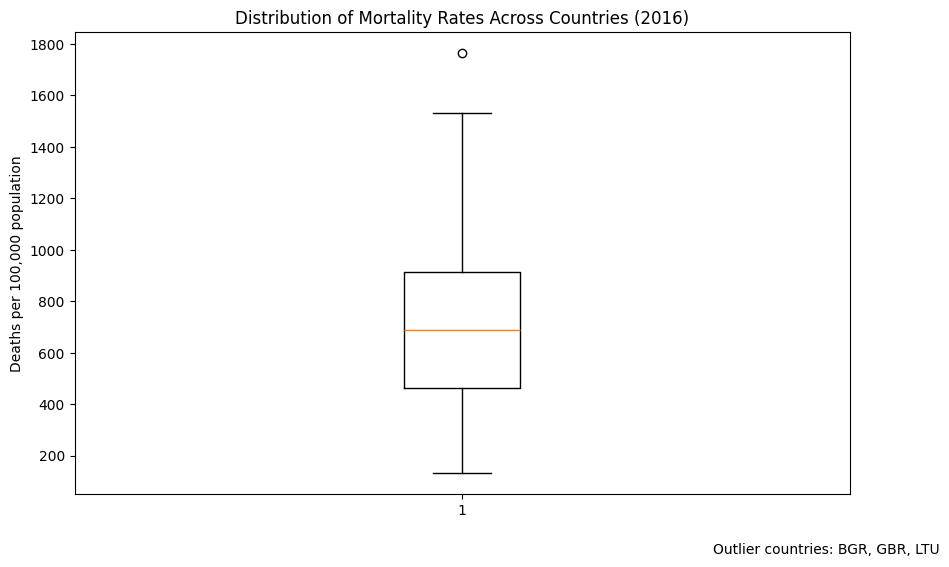

In [ ]:
# -----------------------------
# 5. Country-Mapping für Subregionen
# -----------------------------
country_map = {
    "United States of America": "United States",
    "Czech Republic": "Czechia",
    "Republic of Korea": "Korea, Republic of",
    "Republic of Moldova": "Moldova",
    "Turkey": "Türkiye",
    "Venezuela": "Venezuela, Bolivarian Republic of",

    # UK Subs
    "United Kingdom, England and Wales": "United Kingdom",
    "United Kingdom, Scotland": "United Kingdom",
    "United Kingdom, Northern Ireland": "United Kingdom",

    # China / France Subregions
    "Hong Kong SAR": "Hong Kong",
    "Reunion": "France",
    "Guadeloupe": "France",
    "Martinique": "France",
    "Mayotte": "France",
    "French Guiana": "France",
    "Rodrigues": "Mauritius",
    "Puerto Rico": "United States",
    "Virgin Islands (USA)": "United States",

    # Caribbean and small states
    "Saint Vincent and Grenadines": "Saint Vincent and the Grenadines",
    "Saint Lucia": "Saint Lucia",
    "Saint Kitts and Nevis": "Saint Kitts and Nevis",
    "Grenada": "Grenada",
    "Aruba": "Aruba",
    "Maldives": "Maldives",
    "Bermuda": "Bermuda",
    "Belize": "Belize",
    "British Virgin Islands": "British Virgin Islands",
    "Turks and Caicos Islands": "Turks and Caicos Islands",
    "Montserrat": "Montserrat",
    "Antigua and Barbuda": "Antigua and Barbuda",
    "Cayman Islands": "Cayman Islands"
}

df_2016_unique["Country_clean"] = df_2016_unique["Country"].replace(country_map)

# -----------------------------
# 6. ISO3 Codes generieren
# -----------------------------
def name_to_iso3(country_name):
    try:
        result = pycountry.countries.lookup(country_name)
        return result.alpha_3
    except:
        return None

df_2016_unique["ISO3"] = df_2016_unique["Country_clean"].apply(name_to_iso3)

# Optional: ansehen, welche Länder nicht gemappt wurden
missing_iso = df_2016_unique[df_2016_unique["ISO3"].isna()]["Country"].unique()
print("Fehlende ISO3-Zuordnung:", missing_iso)

# -----------------------------
# 7. World Bank Population-Daten einlesen
# -----------------------------
pop_raw = pd.read_csv("Data_Files\API_SP.POP.TOTL_DS2_en_csv_v2_280659.csv", skiprows=4)

pop_2016 = pop_raw[["Country Code", "2016"]].rename(
    columns={"Country Code": "ISO3", "2016": "Population"}
)

# -----------------------------
# 8. Merge WHO + Population
# -----------------------------
df_merged = df_2016_unique.merge(
    pop_2016,
    on="ISO3",
    how="inner"
)

# -----------------------------
# 9. Todesfälle pro 100k berechnen
# -----------------------------
df_merged["Deaths_per_100k"] = (
    df_merged["Deaths at all ages"] / df_merged["Population"] * 100000
)

# -----------------------------
# 10. Für Boxplot aggregieren
# -----------------------------
mortality_per_country = (
    df_merged.groupby("ISO3")["Deaths_per_100k"]
    .sum()
    .reset_index()
)

print(mortality_per_country.sort_values("Deaths_per_100k", ascending=False).head())

# -----------------------------
# 11. Boxplot zeichnen
# -----------------------------

plt.figure(figsize=(10, 6))
plt.boxplot(mortality_per_country["Deaths_per_100k"], vert=True)

# Outlier highlight
values = mortality_per_country["Deaths_per_100k"].values
iso3 = mortality_per_country["ISO3"].values
outliers = iso3[values > np.percentile(values, 75) + 1.5*np.std(values)]

plt.title("Distribution of Mortality Rates Across Countries (2016)")
plt.ylabel("Deaths per 100,000 population")
plt.figtext(0.99, 0.01, f"Outlier countries: {', '.join(outliers)}", ha="right")
plt.show()



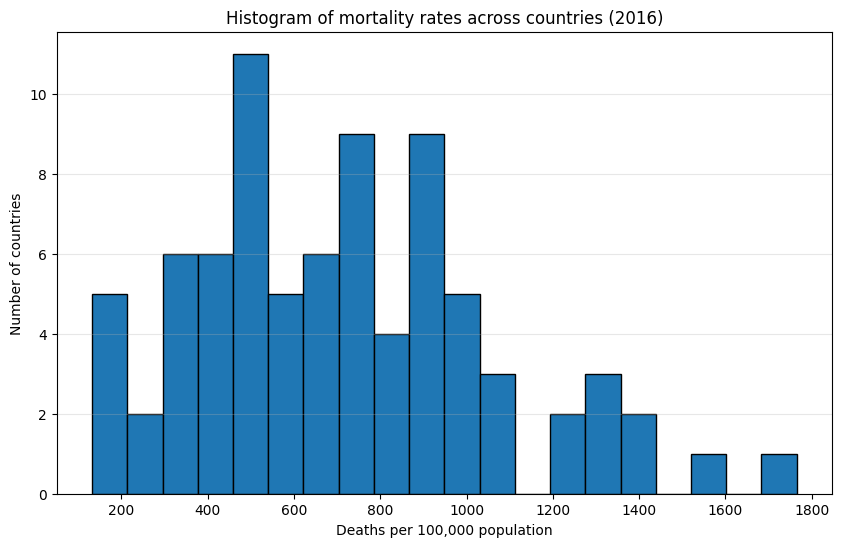

In [12]:
##Histogram plotten
plt.figure(figsize=(10, 6))
plt.hist(mortality_per_country["Deaths_per_100k"], bins=20, edgecolor="black")
plt.xlabel("Deaths per 100,000 population")
plt.ylabel("Number of countries")
plt.title("Histogram of mortality rates across countries (2016)")
plt.grid(axis='y', alpha=0.3)
plt.show()

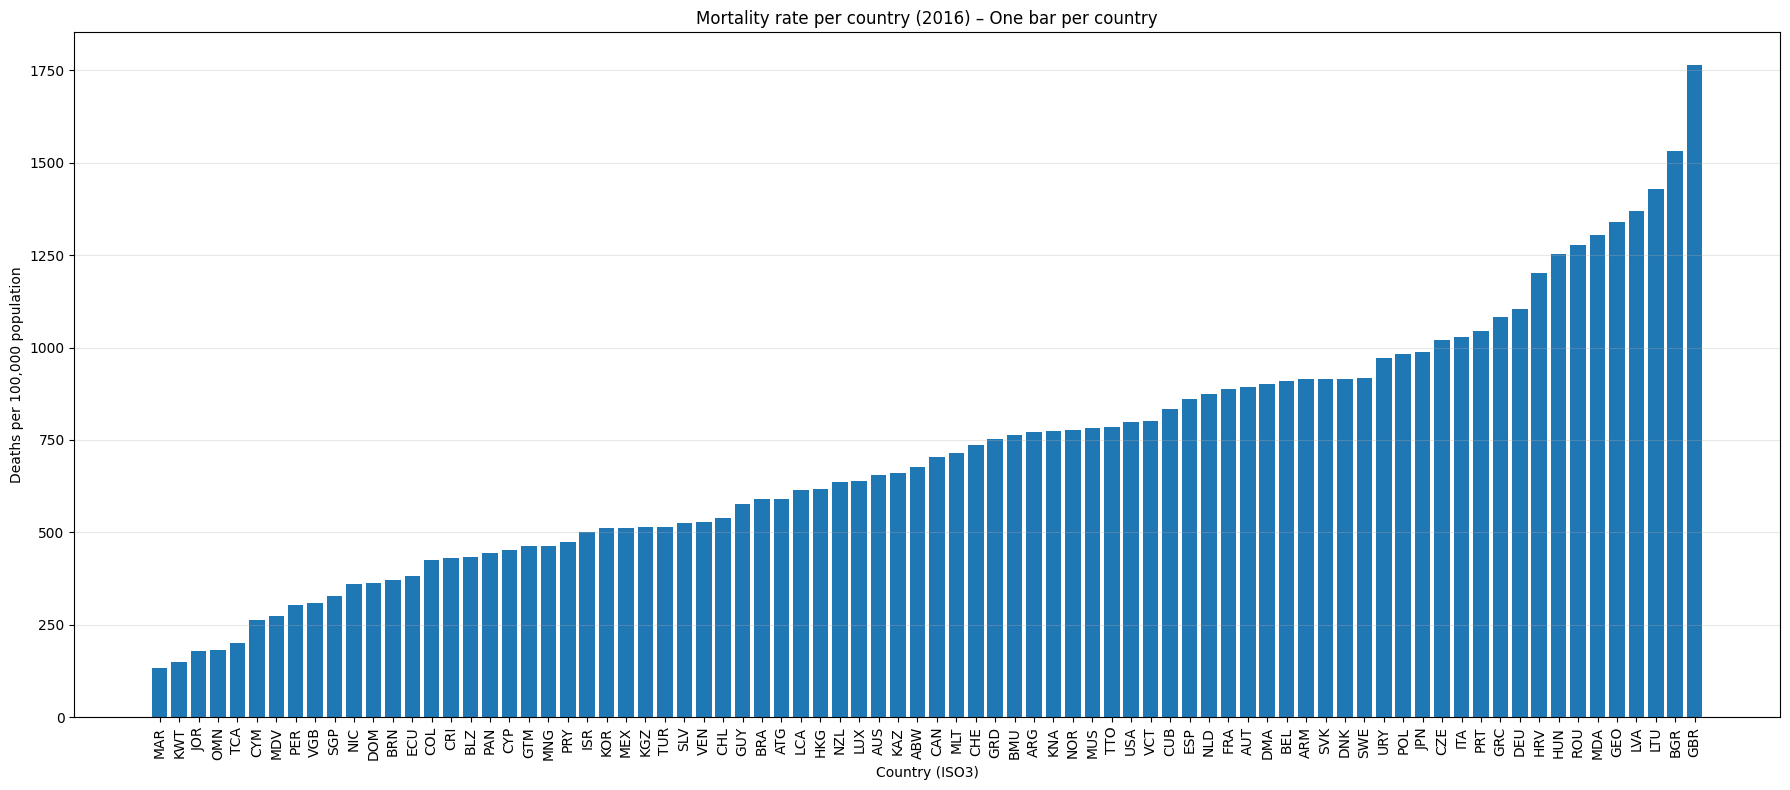

In [13]:
# Sortieren nach Todesrate (optional, sieht schöner aus)
mort_sorted = mortality_per_country.sort_values("Deaths_per_100k")

plt.figure(figsize=(18, 8))
plt.bar(mort_sorted["ISO3"], mort_sorted["Deaths_per_100k"])

plt.xlabel("Country (ISO3)")
plt.ylabel("Deaths per 100,000 population")
plt.title("Mortality rate per country (2016) – One bar per country")

# X-Achse lesbarer machen
plt.xticks(rotation=90)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


Die Schweiz hat eine höhere Mortalitätsrate als Kolumbien,
weil sie eine wesentlich ältere Bevölkerung hat und eine viel höhere Lebenserwartung.
In Ländern mit junger Bevölkerung sterben pro 100’000 Menschen automatisch weniger Leute.

<>:5: SyntaxWarning: invalid escape sequence '\A'
<>:7: SyntaxWarning: invalid escape sequence '\A'
<>:5: SyntaxWarning: invalid escape sequence '\A'
<>:7: SyntaxWarning: invalid escape sequence '\A'
C:\Users\benma\AppData\Local\Temp\ipykernel_25212\1736745157.py:5: SyntaxWarning: invalid escape sequence '\A'
  age_0_14_raw = pd.read_csv("Data_Files\API_SP.POP.0014.TO.ZS_DS2_en_csv_v2_253632.csv", skiprows=4)
C:\Users\benma\AppData\Local\Temp\ipykernel_25212\1736745157.py:7: SyntaxWarning: invalid escape sequence '\A'
  age_65_raw = pd.read_csv("Data_Files\API_SP.POP.65UP.TO.ZS_DS2_en_csv_v2_8582.csv", skiprows=4)


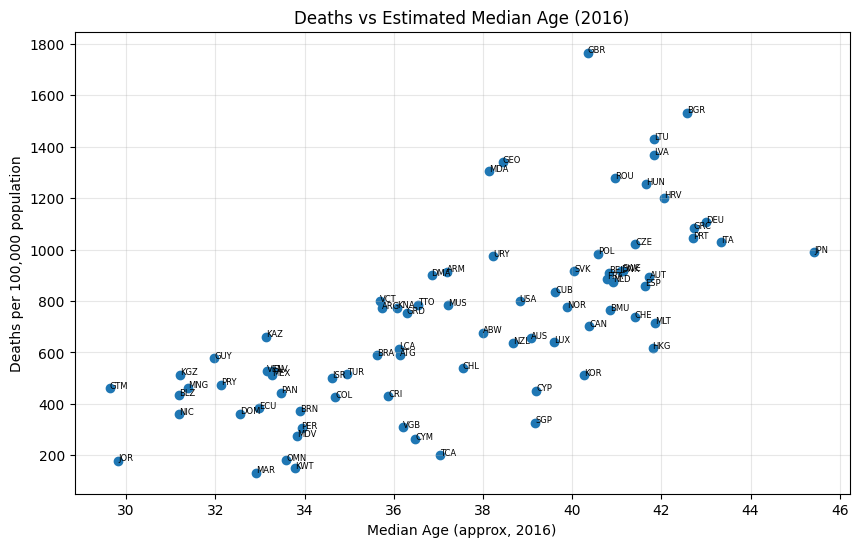

In [18]:
## Deats per 100k vs median age scatter plot
# -----------------------------     

#Daten Einlesen
age_0_14_raw = pd.read_csv("Data_Files\API_SP.POP.0014.TO.ZS_DS2_en_csv_v2_253632.csv", skiprows=4)
age_15_64_raw = pd.read_csv("Data_Files/API_SP.POP.1564.TO.ZS_DS2_en_csv_v2_294218.csv", skiprows=4)
age_65_raw = pd.read_csv("Data_Files\API_SP.POP.65UP.TO.ZS_DS2_en_csv_v2_8582.csv", skiprows=4)


# 2016 Daten extrahieren
age_0_14 = age_0_14_raw[["Country Code", "2016"]].rename(
    columns={"Country Code": "ISO3", "2016": "pct_0_14"}
)

age_15_64 = age_15_64_raw[["Country Code", "2016"]].rename(
    columns={"Country Code": "ISO3", "2016": "pct_15_64"}
)

age_65 = age_65_raw[["Country Code", "2016"]].rename(
    columns={"Country Code": "ISO3", "2016": "pct_65plus"}
)

# Merge Altersdaten
age_all = age_0_14.merge(age_15_64, on="ISO3", how="inner") \
                  .merge(age_65, on="ISO3", how="inner")

#Median Age berechnen
age_all["median_age_proxy"] = (
    7 * (age_all["pct_0_14"] / 100) +
    40 * (age_all["pct_15_64"] / 100) +
    75 * (age_all["pct_65plus"] / 100)
)

# Merge mit Mortalitätsdaten
scatter_data = mortality_per_country.merge(age_all, on="ISO3", how="inner")

# Scatter Plot erstellen
plt.figure(figsize=(10,6))

plt.scatter(scatter_data["median_age_proxy"], scatter_data["Deaths_per_100k"])

plt.xlabel("Median Age (approx, 2016)")
plt.ylabel("Deaths per 100,000 population")
plt.title("Deaths vs Estimated Median Age (2016)")

plt.grid(alpha=0.3)

# Option: Länderlabels anzeigen
for i, row in scatter_data.iterrows():
    plt.text(row["median_age_proxy"], row["Deaths_per_100k"], row["ISO3"], fontsize=6)

plt.show()


